In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import folium
import geopandas as gpd
from shapely.geometry import Point

In [3]:
# load and preprocess data: cali housing

cali_housing_path = '../data/California_Houses.csv'
RANDOM_SEED = 492
cali_df = pd.read_csv(cali_housing_path)
y_series = cali_df['Median_House_Value']
y = pd.DataFrame(y_series, columns=['Median_House_Value'])
features = [col for col in cali_df.columns]
X = cali_df[features]

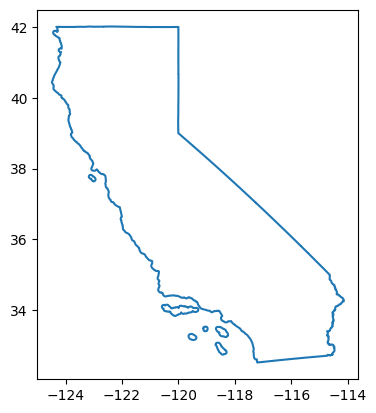

In [4]:
# Create a GeoDataFrame from the data
geometry = [Point(xy) for xy in zip(X['Longitude'], X['Latitude'])]
gdf = gpd.GeoDataFrame(X, geometry=geometry, crs="EPSG:4326")

# Load the California state map
ca_path = '../data/ca_state/CA_State.shp'
california = gpd.read_file(ca_path)
california = california.to_crs("EPSG:4326")
california.boundary.plot()
plt.show()

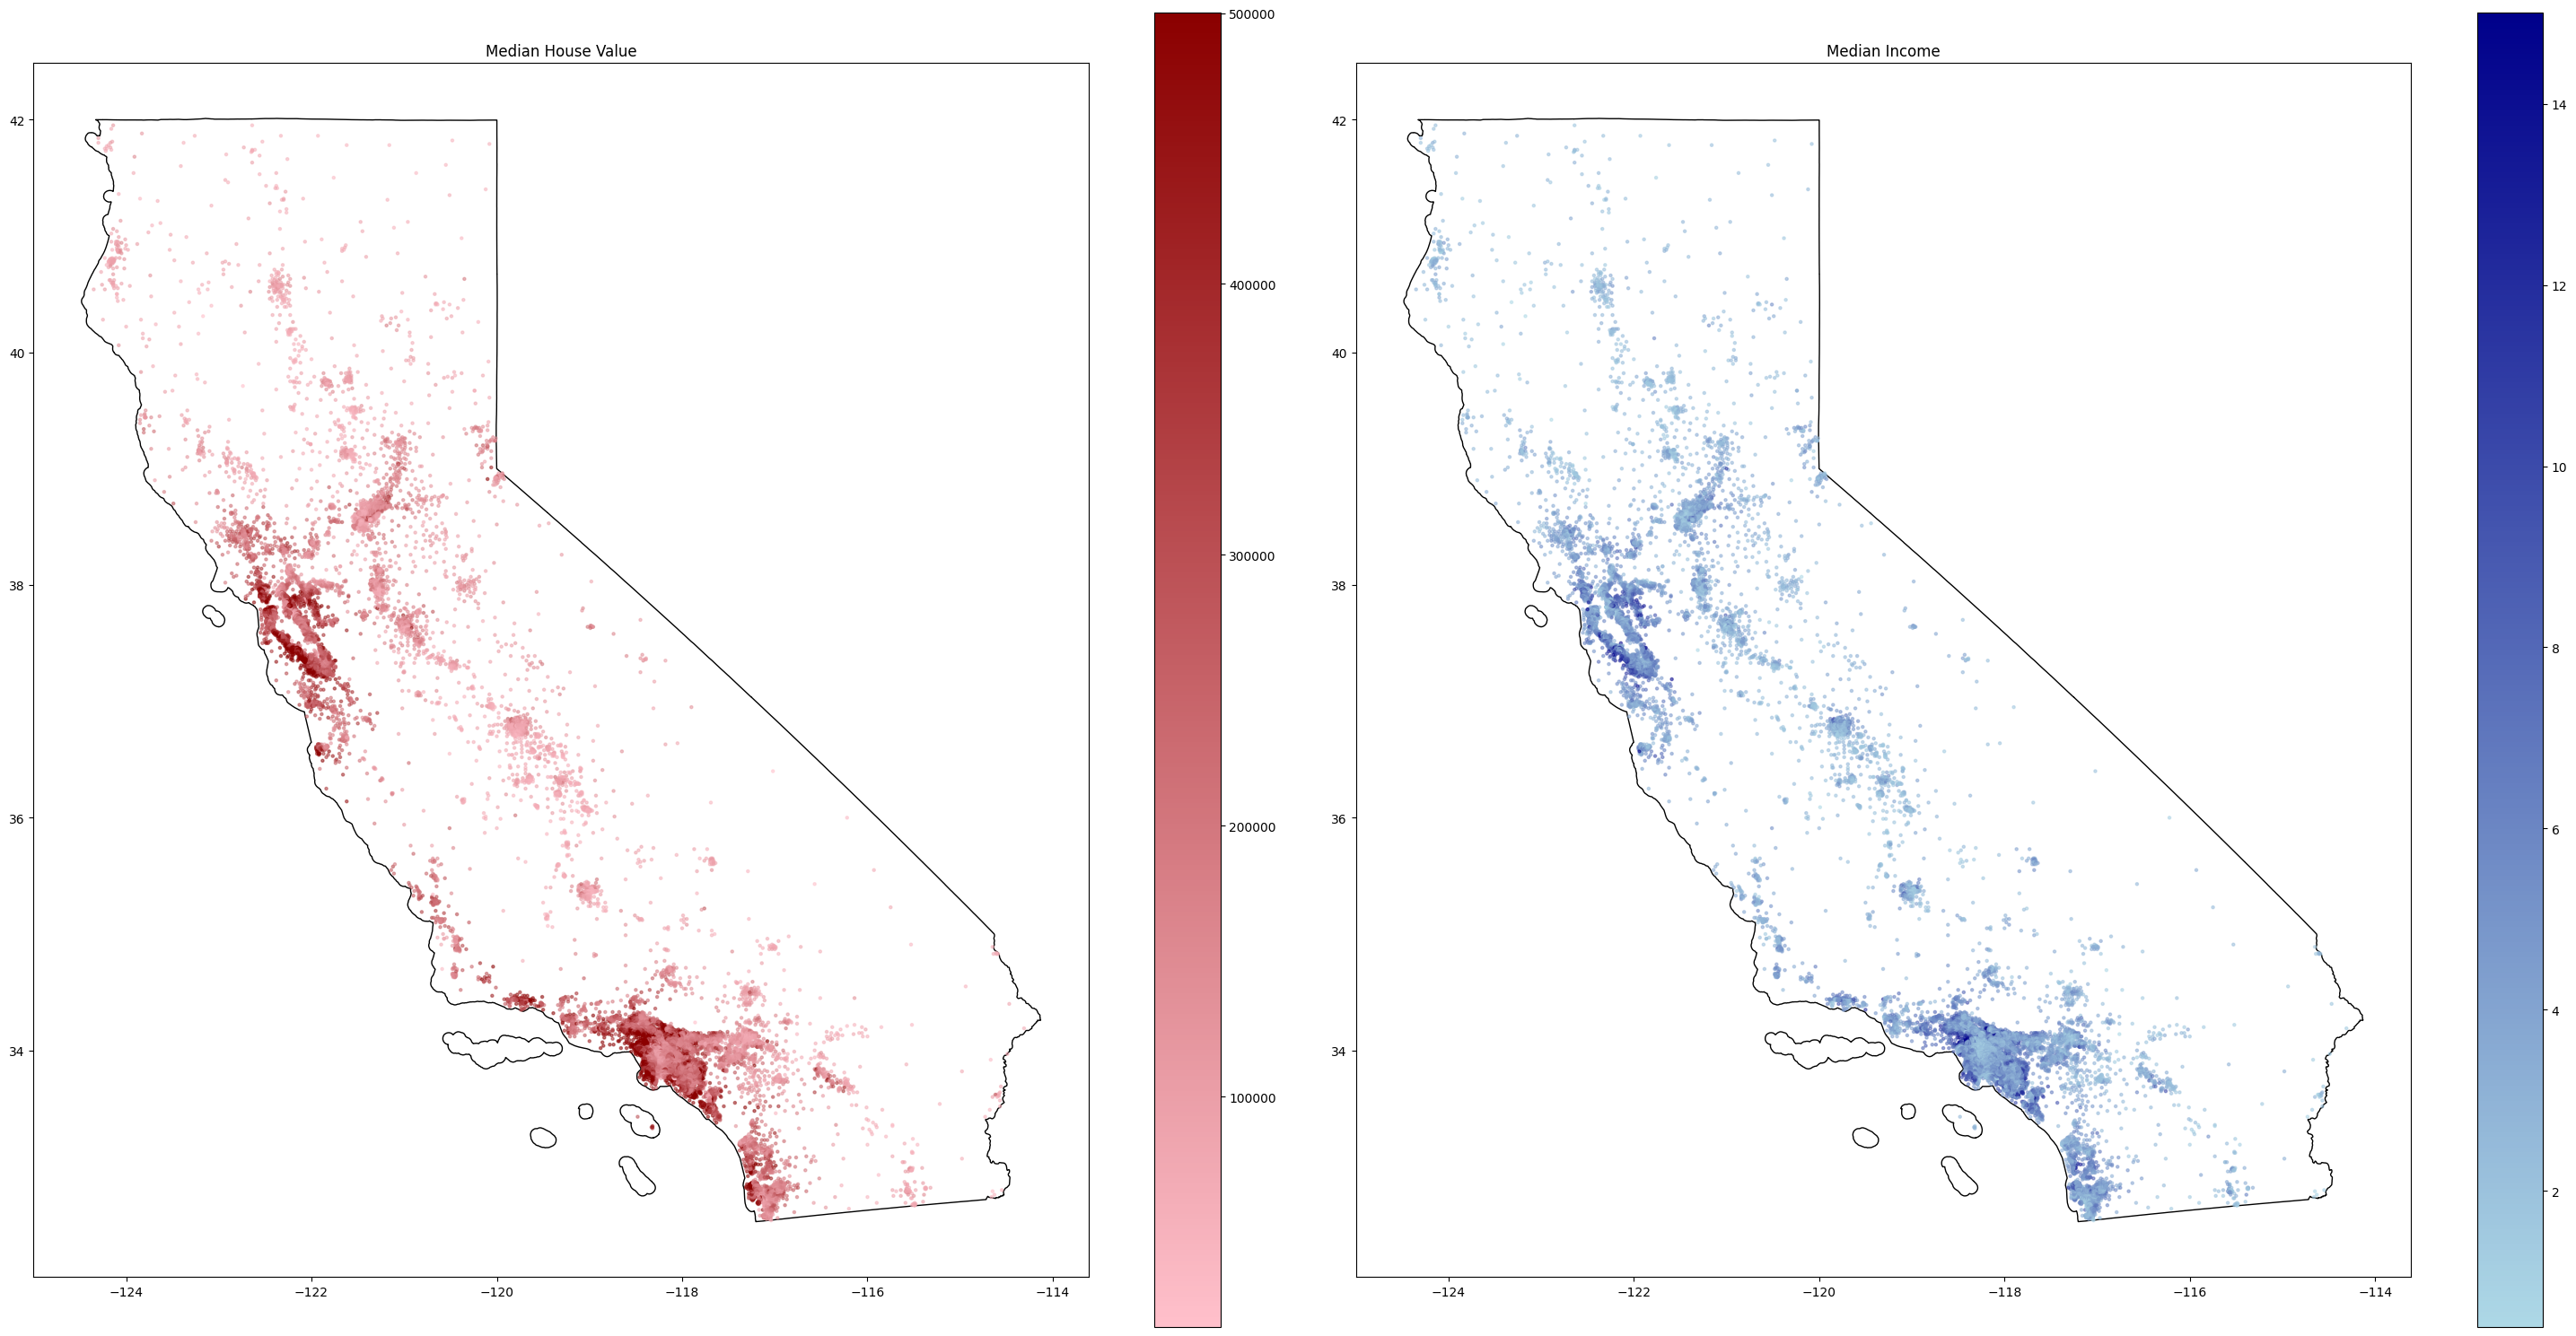

In [5]:

# Define color maps and normalization for each attribute
cmap_house_value = LinearSegmentedColormap.from_list("house_value_cmap", ["pink", "darkred"])
cmap_income = LinearSegmentedColormap.from_list("income_cmap", ["lightblue", "darkblue"])
cmap_distance = plt.get_cmap('coolwarm')

norm_house_value = mcolors.Normalize(vmin=gdf['Median_House_Value'].min(), vmax=gdf['Median_House_Value'].max())
norm_income = mcolors.Normalize(vmin=gdf['Median_Income'].min(), vmax=gdf['Median_Income'].max())
norm_distance = mcolors.Normalize(vmin=gdf['Distance_to_coast'].min(), vmax=gdf['Distance_to_coast'].max())


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(30, 15))

# Plot for median house value
base = california.plot(ax=axes[0], color='white', edgecolor='black')
gdf.plot(ax=base, marker='o', column='Median_House_Value', cmap=cmap_house_value, markersize=5, alpha=0.5, legend=True, norm=norm_house_value)
axes[0].set_title('Median House Value')
# axes[0].set_xlabel('Longitude')
# axes[0].set_ylabel('Latitude')

# Plot for median income
base = california.plot(ax=axes[1], color='white', edgecolor='black')
gdf.plot(ax=base, marker='o', column='Median_Income', cmap=cmap_income, markersize=5, alpha=0.5, legend=True, norm=norm_income)
axes[1].set_title('Median Income')
# axes[1].set_xlabel('Longitude')
# axes[1].set_ylabel('Latitude')

# # Plot for distance to coast
# base = california.plot(ax=axes[2], color='white', edgecolor='black')
# gdf.plot(ax=base, marker='o', column='Distance_to_coast', cmap=cmap_distance, markersize=5, alpha=0.5, legend=True, norm=norm_distance)
# axes[2].set_title('Distance to Coast')
# axes[2].set_xlabel('Longitude')
# axes[2].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

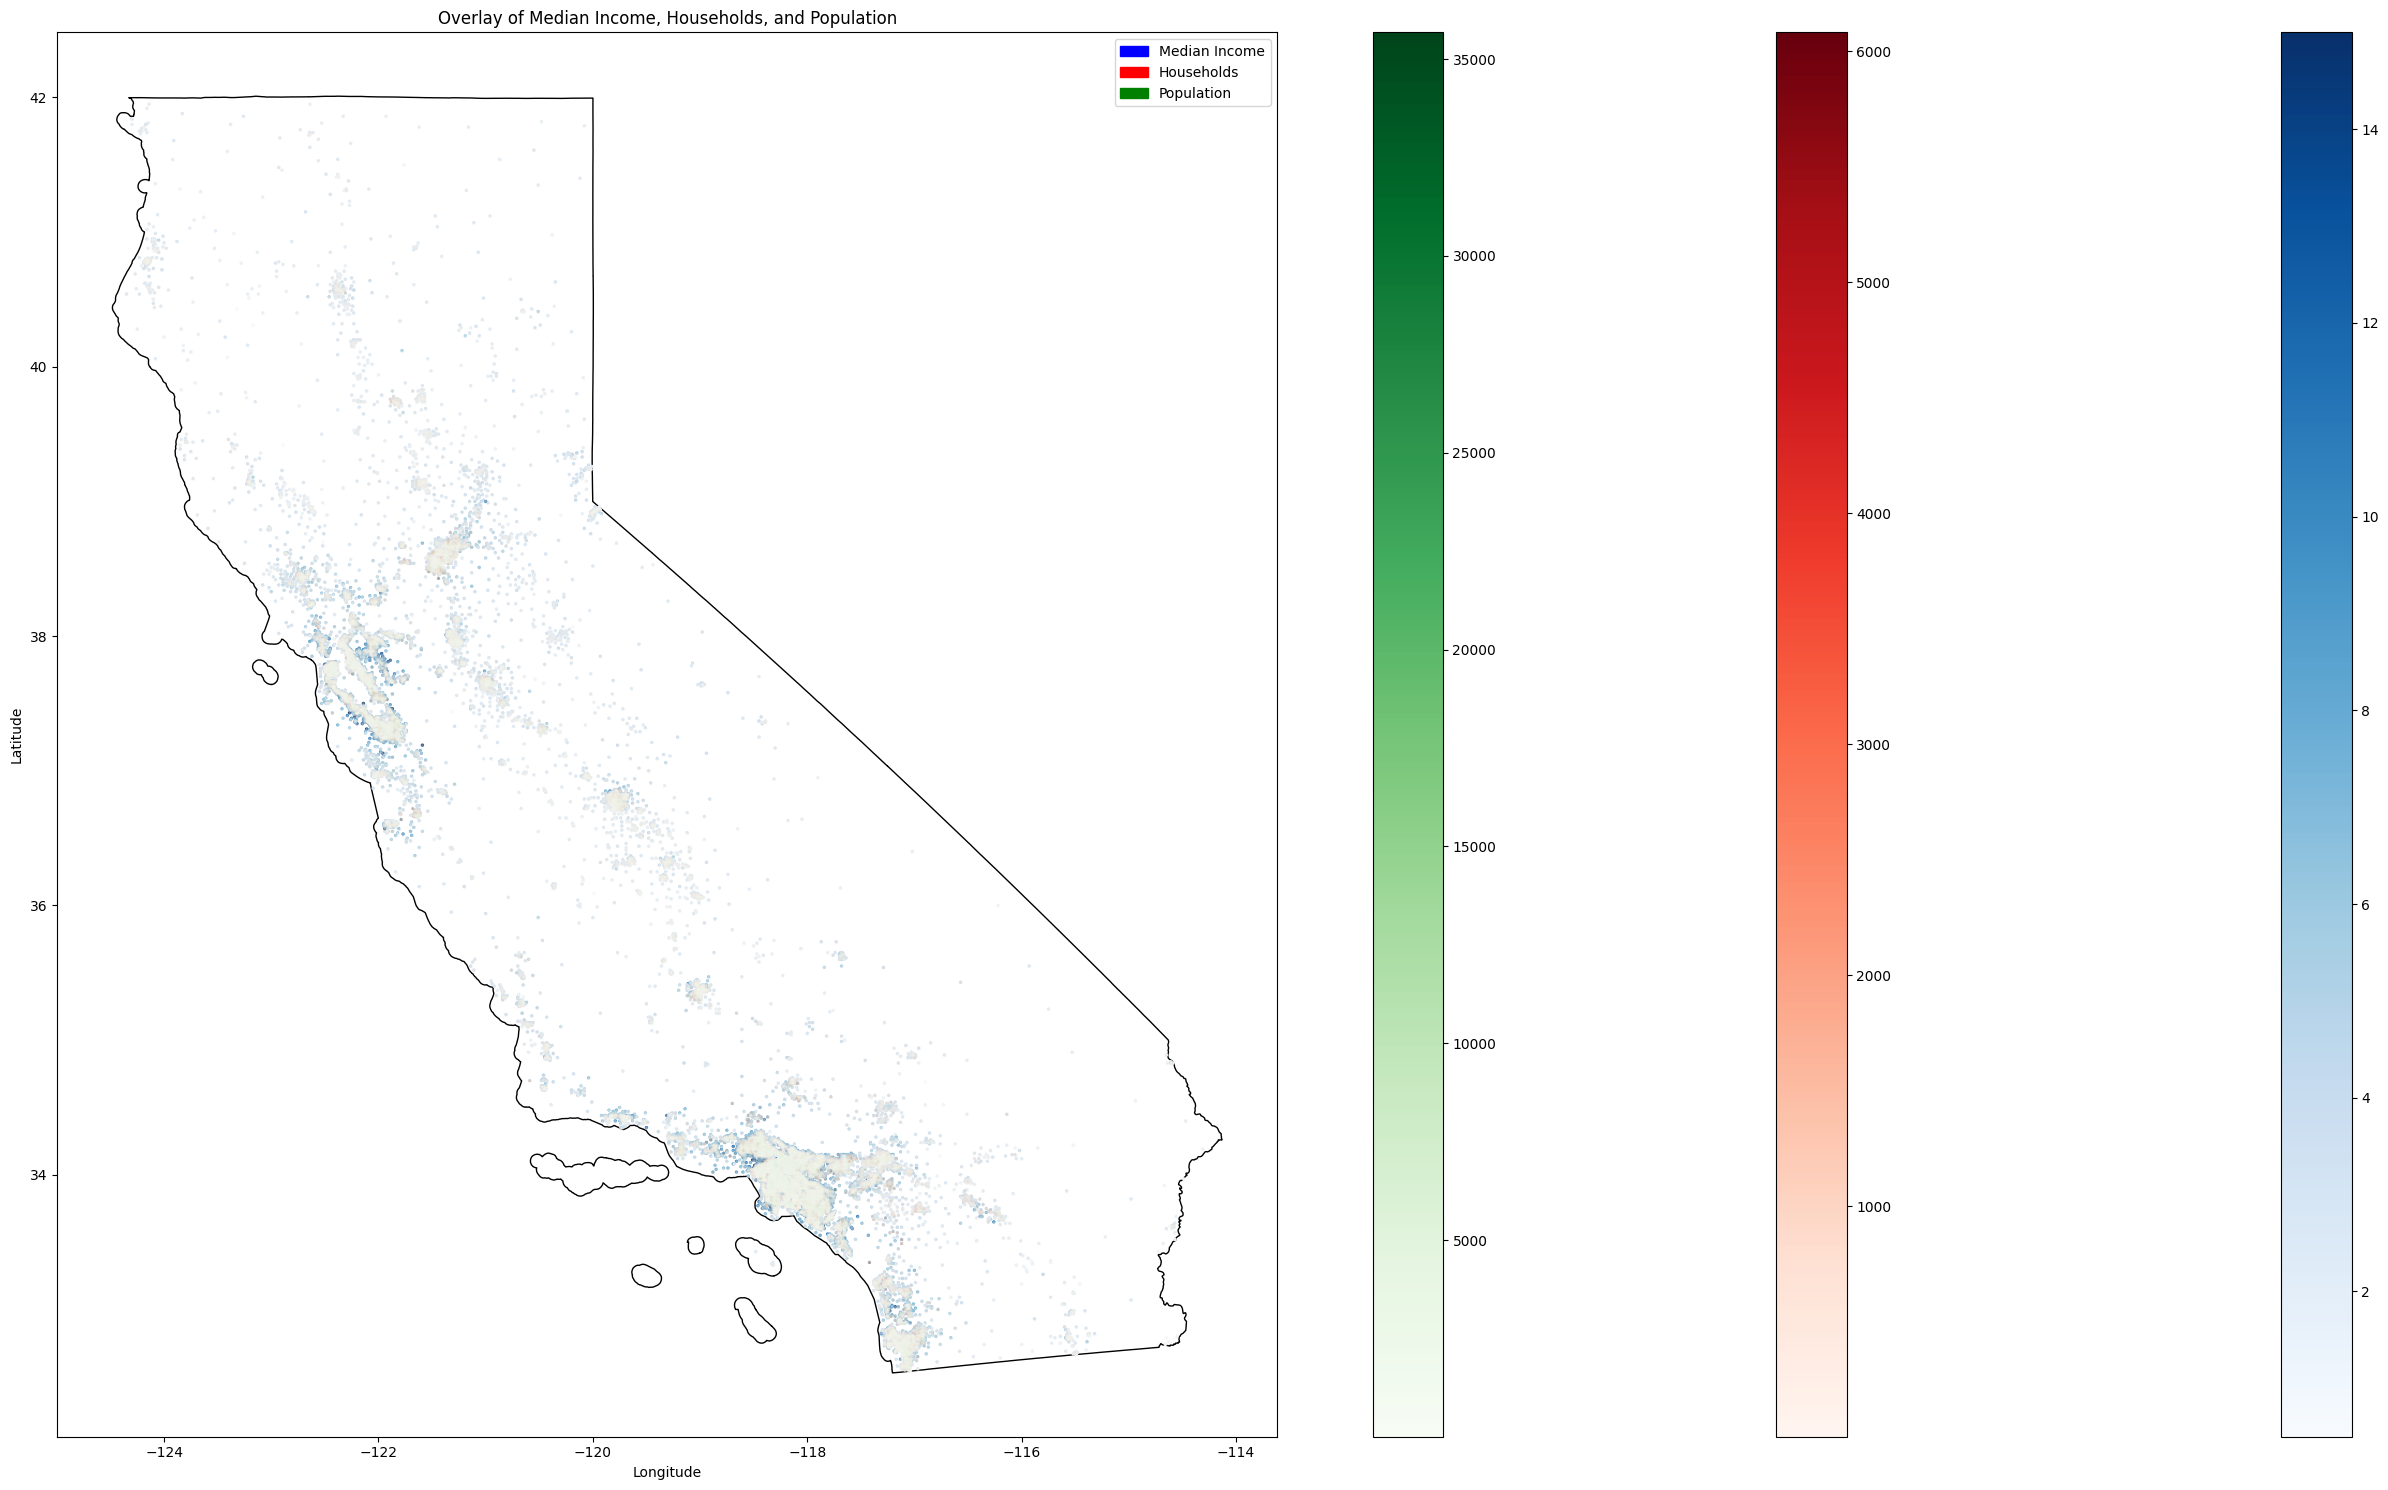

In [14]:
# Create a figure and axes
fig, ax = plt.subplots(1, 1, figsize=(30, 15))

# Plot the base map
base = california.plot(ax=ax, color='white', edgecolor='black')

# Overlay Median Income
gdf.plot(ax=base, marker='o', column='Median_Income', cmap='Blues', markersize=2, alpha=1, legend=True, label='Median Income')

# Overlay Households
gdf.plot(ax=base, marker='^', column='Households', cmap='Reds', markersize=2, alpha=0.2, legend=True, label='Households')

# Overlay Population
gdf.plot(ax=base, marker='s', column='Population', cmap='Greens', markersize=2, alpha=0.1, legend=True, label='Population')

# Add titles and labels
ax.set_title('Overlay of Median Income, Households, and Population')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Create a custom legend
import matplotlib.patches as mpatches
income_patch = mpatches.Patch(color='blue', label='Median Income')
households_patch = mpatches.Patch(color='red', label='Households')
population_patch = mpatches.Patch(color='green', label='Population')
plt.legend(handles=[income_patch, households_patch, population_patch])

plt.tight_layout()
plt.show()

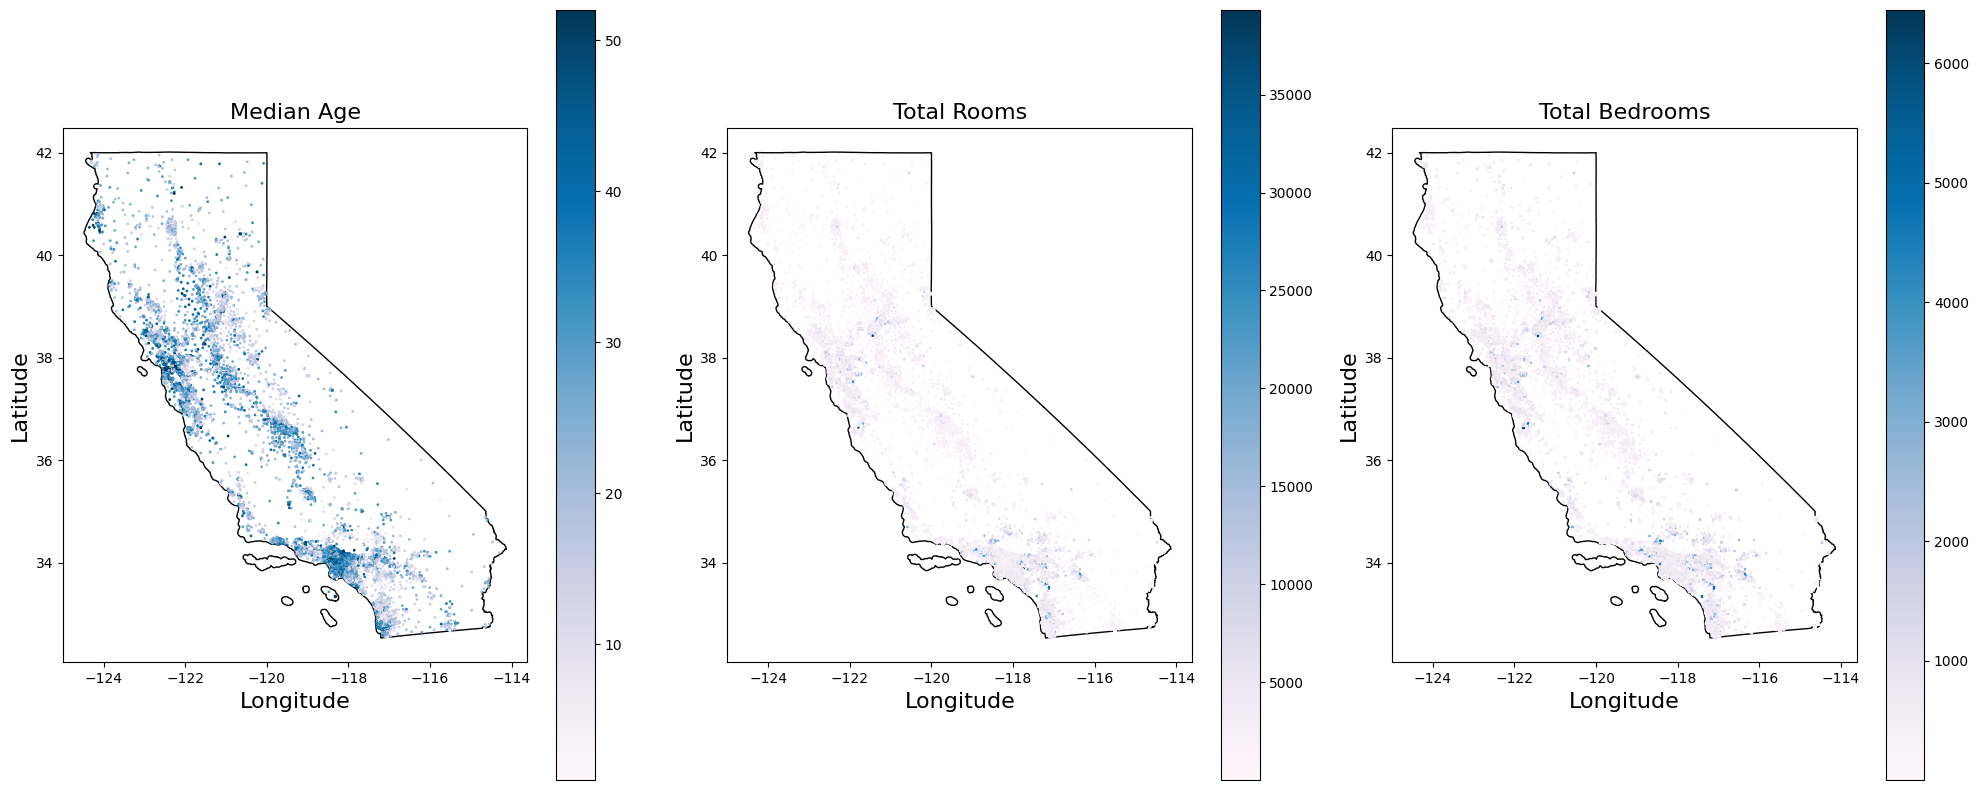

In [60]:
# Create a figure and axes for three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Plot Median Income
base = california.plot(ax=axes[0], color='white', edgecolor='black')
gdf.plot(ax=base, marker='o', column='Median_Age', cmap='PuBu', markersize=1, alpha=1, legend=True)
axes[0].set_title('Median Age', fontsize=16)
axes[0].set_xlabel('Longitude', fontsize=16)
axes[0].set_ylabel('Latitude', fontsize=16)


# Plot Households
base = california.plot(ax=axes[1], color='white', edgecolor='black')
gdf.plot(ax=base, marker='^', column='Tot_Rooms', cmap='PuBu', markersize=1, alpha=1, legend=True)
axes[1].set_title('Total Rooms', fontsize=16)
axes[1].set_xlabel('Longitude', fontsize=16)
axes[1].set_ylabel('Latitude', fontsize=16)

# Plot Population
base = california.plot(ax=axes[2], color='white', edgecolor='black')
gdf.plot(ax=base, marker='s', column='Tot_Bedrooms', cmap='PuBu', markersize=1, alpha=1, legend=True)
axes[2].set_title('Total Bedrooms', fontsize=16)
axes[2].set_xlabel('Longitude', fontsize=16)
axes[2].set_ylabel('Latitude', fontsize=16)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

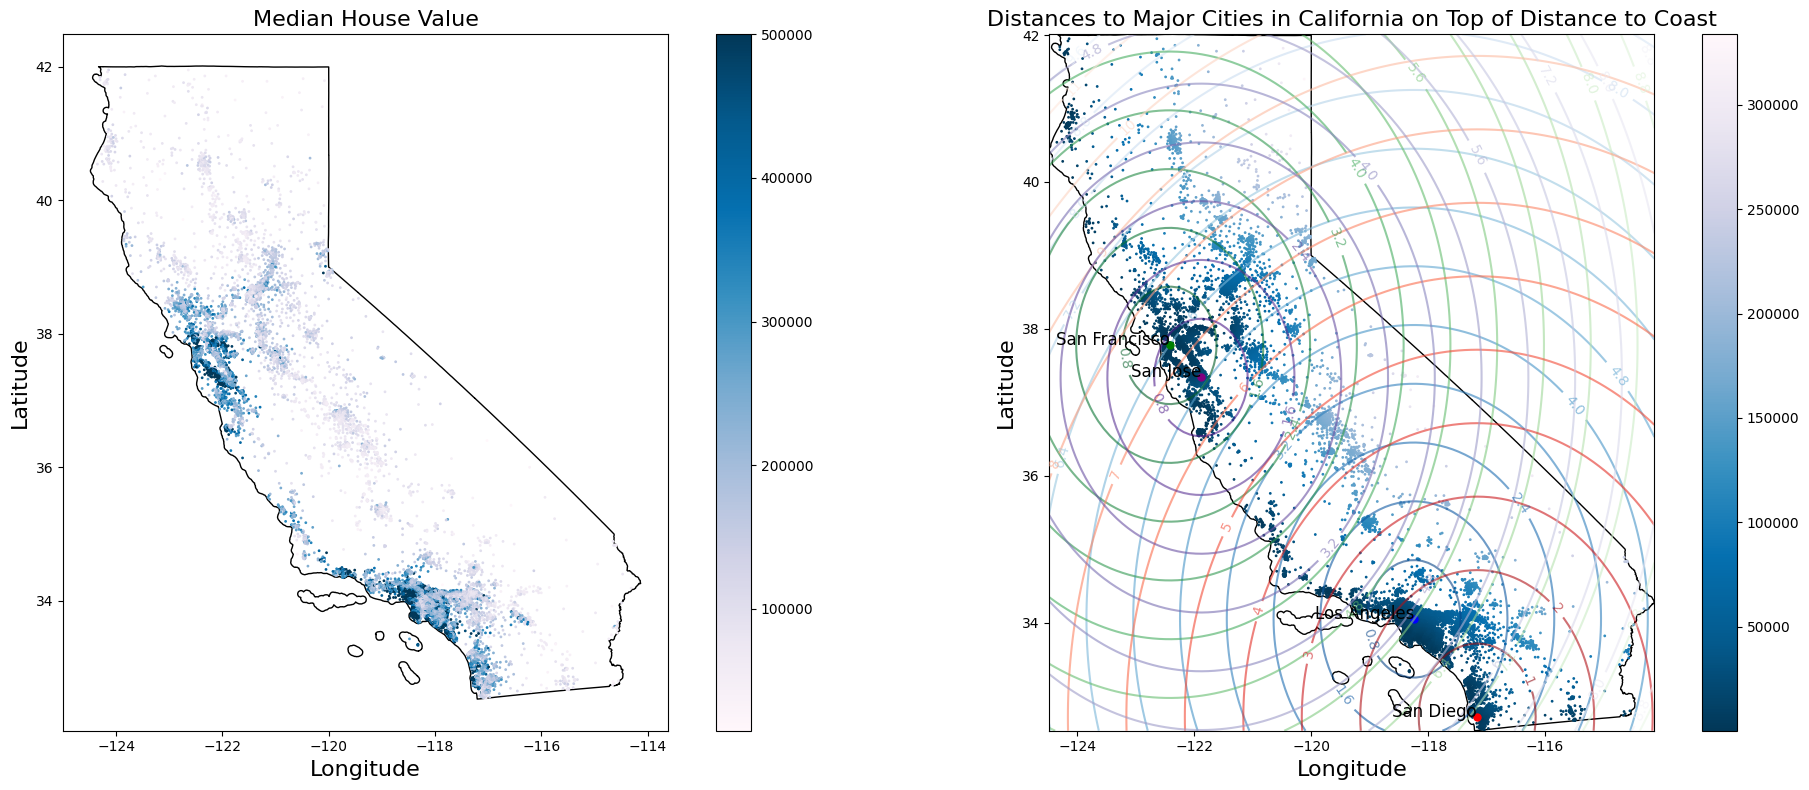

In [59]:
from scipy.spatial import distance
from shapely.geometry import Point, LineString
# Create a figure and axes for three subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Median Income
base = california.plot(ax=axes[0], color='white', edgecolor='black')
gdf.plot(ax=base, marker='o', column='Median_House_Value', cmap='PuBu', markersize=1, alpha=1, legend=True)
axes[0].set_title('Median House Value', fontsize=16)
axes[0].set_xlabel('Longitude', fontsize=16)
axes[0].set_ylabel('Latitude', fontsize=16)


cities = {
    'Los Angeles': {'coords': (-118.2437, 34.0522), 'color': 'Blues_r', 'marker': 'blue'},
    'San Francisco': {'coords': (-122.4194, 37.7749), 'color': 'Greens_r', 'marker': 'green'},
    'San Diego': {'coords': (-117.1611, 32.7157), 'color': 'Reds_r', 'marker': 'red'},
    'San Jose': {'coords': (-121.8863, 37.3382), 'color': 'Purples_r', 'marker': 'purple'}
}

# Generate a grid of points covering California
x = np.linspace(california.total_bounds[0], california.total_bounds[2], 100)
y = np.linspace(california.total_bounds[1], california.total_bounds[3], 100)
X, Y = np.meshgrid(x, y)
grid_points = np.c_[X.ravel(), Y.ravel()]

# Calculate distances from each grid point to each city
distances = {city: distance.cdist(grid_points, [data['coords']]) for city, data in cities.items()}

# Create a figure and axis
# Plot the base map
base = california.plot(ax=axes[1], color='white', edgecolor='black')

gdf.plot(ax=base, marker='o', column='Distance_to_coast', cmap='PuBu_r', markersize=1, alpha=1, legend=True)
# Overlay contour plots for each city
for city, data in cities.items():
    dist = distances[city].reshape(X.shape)
    contour = axes[1].contour(X, Y, dist, levels=12, cmap=data['color'], alpha=0.6)
    axes[1].clabel(contour, inline=True, fontsize=10)
    axes[1].plot(*data['coords'], 'o', markersize=5, color=data['marker'], label=city)
    axes[1].text(data['coords'][0], data['coords'][1], city, fontsize=12, ha='right')

# Add titles and labels
axes[1].set_title('Distances to Major Cities in California on Top of Distance to Coast', fontsize=16)
axes[1].set_xlabel('Longitude', fontsize=16)
axes[1].set_ylabel('Latitude', fontsize=16)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

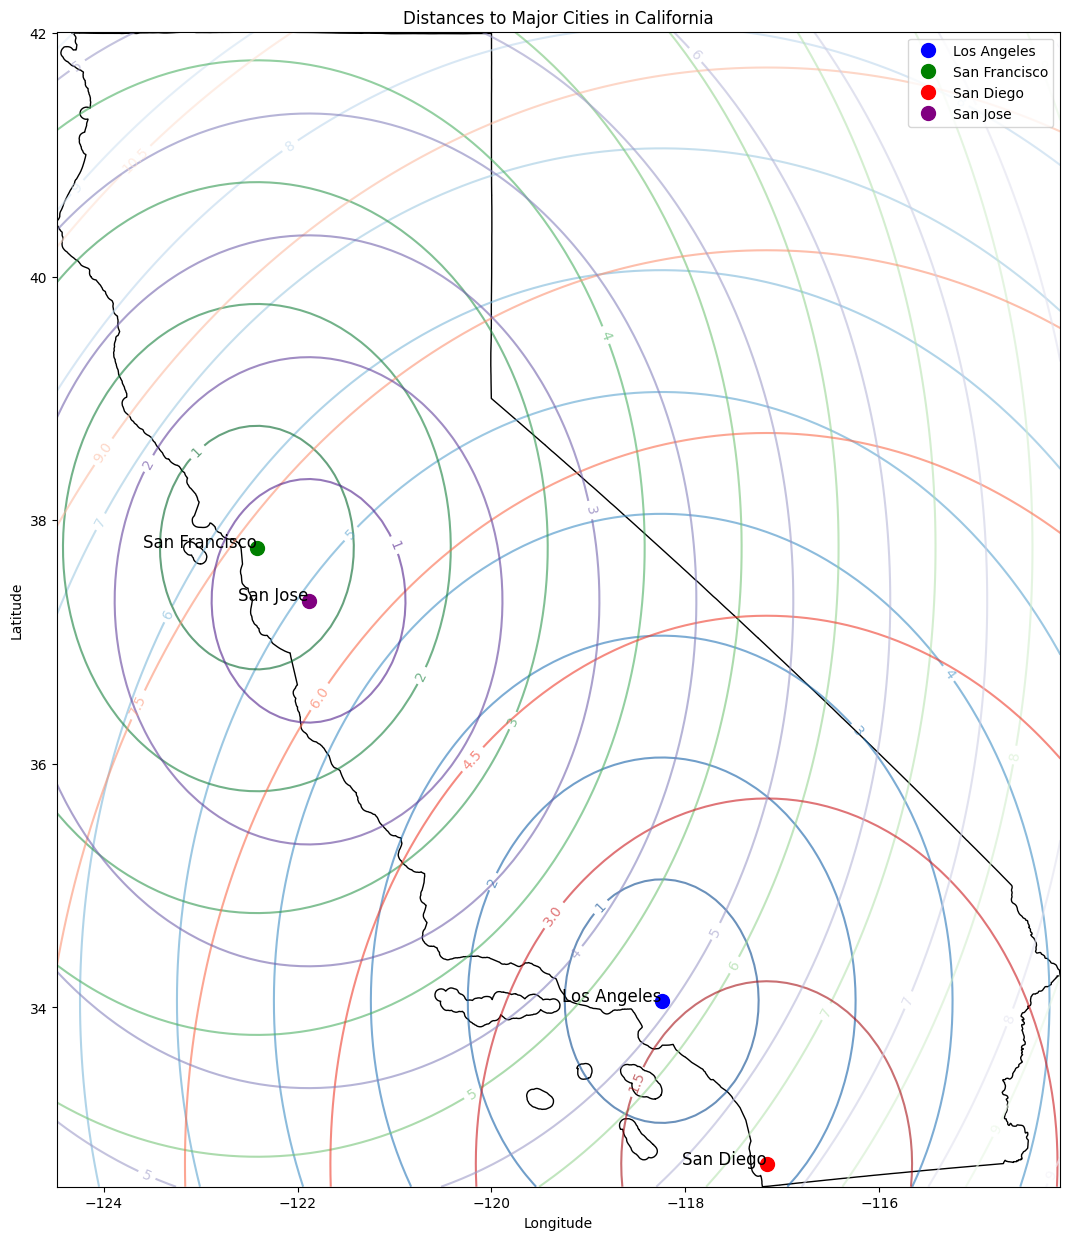

In [45]:
from scipy.spatial import distance
from shapely.geometry import Point
# Define cities with their coordinates (longitude, latitude)
# Define cities with their coordinates (longitude, latitude)
# Define cities with their coordinates (longitude, latitude) and colormaps
cities = {
    'Los Angeles': {'coords': (-118.2437, 34.0522), 'color': 'Blues_r', 'marker': 'blue'},
    'San Francisco': {'coords': (-122.4194, 37.7749), 'color': 'Greens_r', 'marker': 'green'},
    'San Diego': {'coords': (-117.1611, 32.7157), 'color': 'Reds_r', 'marker': 'red'},
    'San Jose': {'coords': (-121.8863, 37.3382), 'color': 'Purples_r', 'marker': 'purple'}
}

# Generate a grid of points covering California
x = np.linspace(california.total_bounds[0], california.total_bounds[2], 100)
y = np.linspace(california.total_bounds[1], california.total_bounds[3], 100)
X, Y = np.meshgrid(x, y)
grid_points = np.c_[X.ravel(), Y.ravel()]

# Calculate distances from each grid point to each city
distances = {city: distance.cdist(grid_points, [data['coords']]) for city, data in cities.items()}

# Create a figure and axis
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the base map
base = california.plot(ax=ax, color='white', edgecolor='black')

# Overlay contour plots for each city
for city, data in cities.items():
    dist = distances[city].reshape(X.shape)
    contour = ax.contour(X, Y, dist, levels=10, cmap=data['color'], alpha=0.6)
    ax.clabel(contour, inline=True, fontsize=10)
    ax.plot(*data['coords'], 'o', markersize=10, color=data['marker'], label=city)
    ax.text(data['coords'][0], data['coords'][1], city, fontsize=12, ha='right')

# Add titles and labels
ax.set_title('Distances to Major Cities in California')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add legend
ax.legend()

# Show plot
plt.show()